Trying to reproduce phase diagrams from: 

- [Quantum correlations, entanglement spectrum and coherence of two-particle reduced density matrix in the Extended Hubbard Model](https://arxiv.org/pdf/2111.00085)

- [Formation of spin and charge ordering in the extended Hubbard model during a finite-time quantum quench](https://arxiv.org/pdf/2208.05945)


- [Entanglement of indistinguishable particles as a probe for quantum phase transitions in the extended Hubbard model](https://arxiv.org/pdf/1503.08188)

In [ ]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os
from scipy.ndimage import gaussian_filter
%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

fig_path = f"{figures_path}/{model}_{exec}/XXXXX"

In [2]:
N_Points = 50
L = 5

In [3]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [4]:
def load_scalar_data(results, model, exec, L, N_Points):
    info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df = pd.read_csv(info_input)

    U_vals = np.sort(df['U'].unique())
    V_vals = np.sort(df['V'].unique())

    U_unique = np.sort(df['U'].unique())
    V_unique = np.sort(df['V'].unique())

    nU = len(U_vals)
    nV = len(V_vals)
    
    Q_2 =           df['Q_2'].values.reshape(nV, nU).T
    Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

    avg_linear_entropy = df['coh_1rdm'].values.reshape(nV, nU).T
    quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

    E_p =           df['E_p'].values.reshape(nV, nU).T
    E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
    E_GS =         df['E_GS'].values.reshape(nV, nU).T

    m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
    m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

    avg_linear_entropy = df['S'].values.reshape(nV, nU).T

    return df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, avg_linear_entropy, Q_2, Q_2_bits, quantum_coherence_2

In [5]:
def load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points):
    magnetization = np.zeros((nV, nU, L))
    charge_density = np.zeros((nV, nU, L))
    doublons = np.zeros((nV, nV, L))

    ent_spec_1rdm = np.zeros((nV, nV, 2*L))
    ent_spec_2rdm = np.zeros((nV, nV, L*(2*L-1)))

    info_input = f"{results}/{model}_{exec}/vector_measures_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df_vecs = pd.read_csv(info_input)

    # Loading the 1-dimensional data frame values. 

    def parse_array(cell):
        return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

    # Apply parsing
    df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
    df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)
    df_vecs["doublons"] = df_vecs["doublons"].apply(parse_array)
    # df_vecs["Omega_1rdm"] = df_vecs["Omega_1rdm"].apply(parse_array)
    # df_vecs["Omega_2rdm"] = df_vecs["Omega_2rdm"].apply(parse_array)

    # thanks gpt
    for _, row in df_vecs.iterrows():
        i = np.where(V_unique == row["V"])[0][0]
        j = np.where(U_unique == row["U"])[0][0]
        magnetization[i, j] = row["magnetization"]
        charge_density[i, j] = row["charge_density"]
        doublons[i, j] = row["doublons"]

        # ent_spec_1rdm[i, j] = row["Omega_1rdm"]
        # ent_spec_2rdm[i, j] = row["Omega_2rdm"]

    return magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm

In [6]:
df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2  = load_scalar_data(results, model, exec, L, N_Points)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

In [7]:
magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points)

In [8]:
tmp = df['E_p'].values.reshape(nV, nU).T

U_target = 5.51
i_U_fixed = np.argmin(np.abs(U_vals - U_target))

print(tmp[i_U_fixed, :])

[0.01461132 0.01447992 0.0143392  0.01420028 0.01406051 0.01392045
 0.01378082 0.01364242 0.01350638 0.01337368 0.01324571 0.01312394
 0.01301008 0.01290611 0.01281426 0.01273712 0.01267763 0.01263913
 0.01262546 0.01264097 0.01269061 0.01278    0.01291547 0.01310418
 0.01335418 0.01367451 0.01407526 0.01456771 0.0151644  0.01587926
 0.01672772 0.01772682 0.01889542 0.02025424 0.02182617 0.02363635
 0.02571252 0.02808525 0.03078836 0.03385946 0.03734063 0.04127945
 0.04573028 0.05075586 0.05642908 0.06283487 0.07007238 0.07825743
 0.08752449 0.09802613]


In [9]:
# gaps_1rdm = np.diff(ent_spec_1rdm)#[0, 0]
# gaps_2rdm = np.diff(ent_spec_2rdm)#[0, 0]

In [10]:
V_targets_negatives = np.sort([-1.53, -1.32, -1.12, -0.92, -0.72])
V_targets_positives = np.sort([0.1]) # , 0.9, 1.6, 2.32, 1.12, 1.7, 2.1, 3.0])
U_targets_negatives = np.sort([-5.73, -4.75, -2.85, -1.76 ,-0.95, 0.0])
U_targets_positives = np.sort([2.3, 2.6, 0.1, 0.5, 1.5, 3.1, 4.3, 6.0])

# transposing the data was only needed to make the full diagram
Q_2 =           df['Q_2'].values.reshape(nV, nU)# .T

quantum_coherence_1 = df['coh_1rdm'].values.reshape(nV, nU)# .T
quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU)# .T

E_p =           df['E_p'].values.reshape(nV, nU)# .T

#### Fixed $V$ values

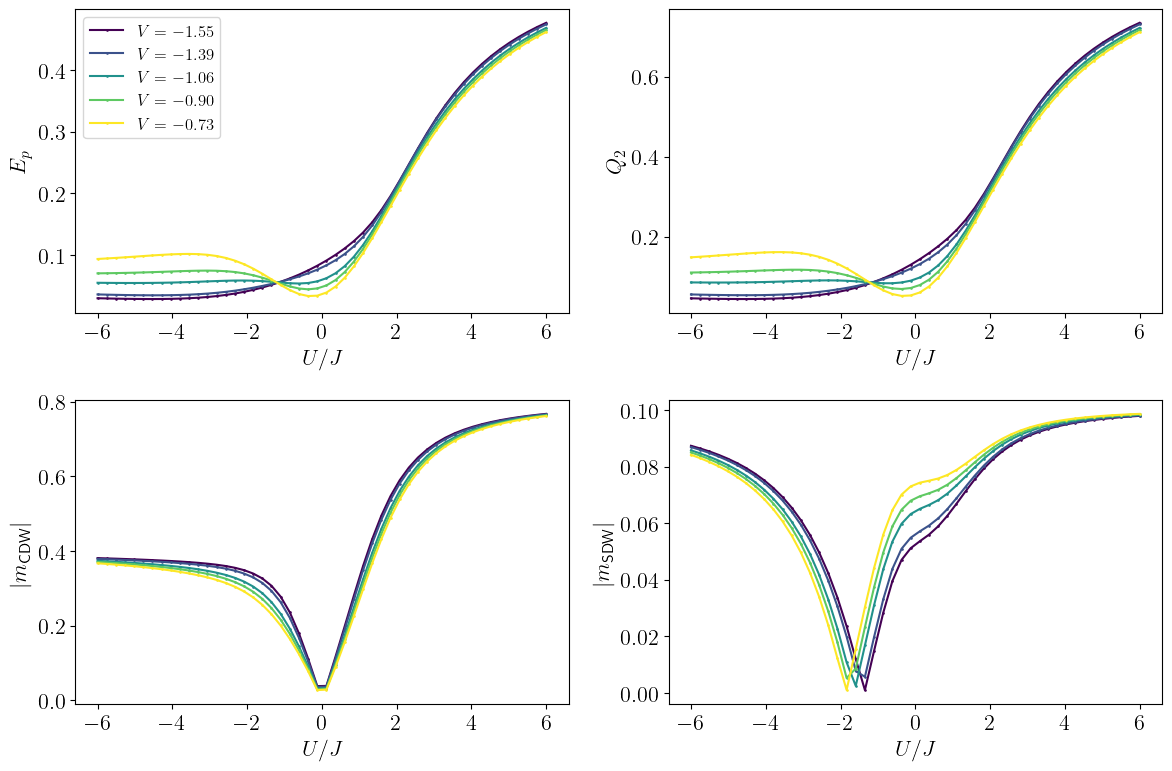

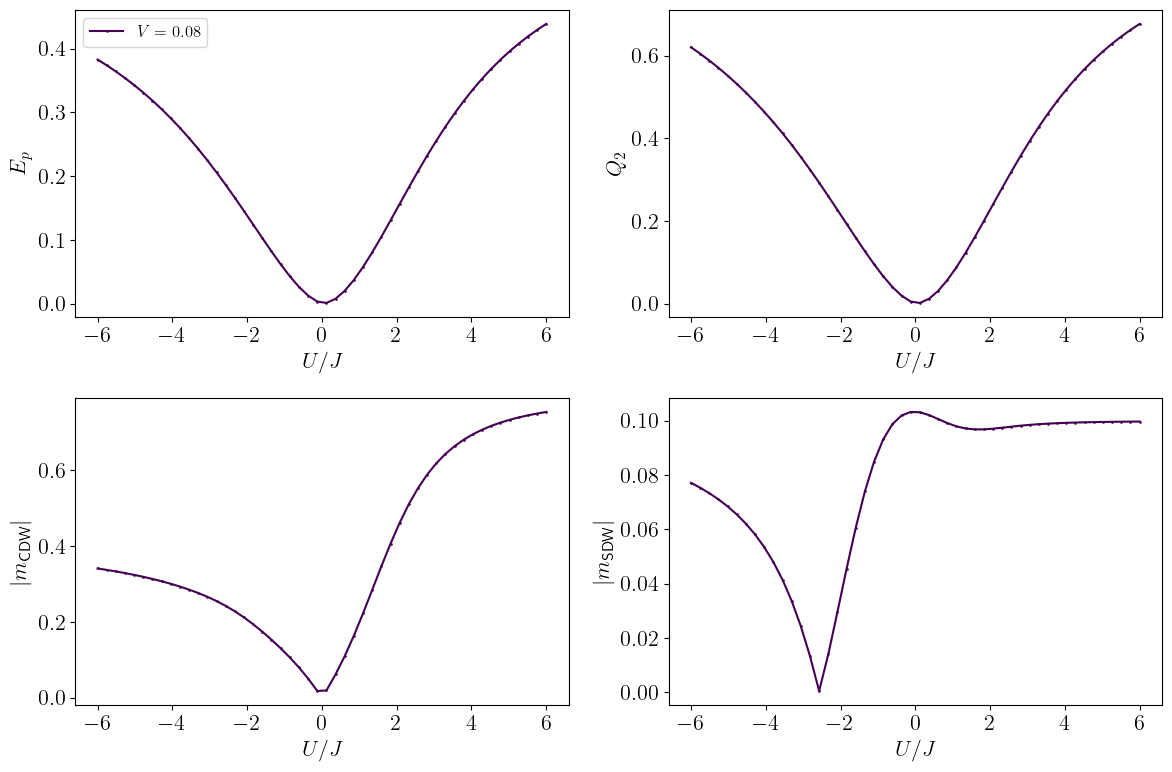

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")#a62828
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()

# Positive V plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

In [12]:
def plot_cut_phase_diagram(
    x_vals, y_vals, measure, targets, y_label, x_label, fname,
    title=None, phase_boundaries=None, fixed_axis="y"):
    """
    Plot 1D cuts of a 2D measure along either x or y, fixing the other axis.

    Parameters
    ----------
    x_vals : array
        Values of the x-axis (e.g. U).
    y_vals : array
        Values of the y-axis (e.g. V).
    measure : 2D array
        Measure values with shape (len(x_vals), len(y_vals)).
    targets : list
        Values to fix along the chosen axis (fixed_axis).
    y_label : str
        Label for the plot's y-axis.
    x_label : str
        Label for the plot's x-axis.
    fname : str
        Output filename for saving the figure.
    title : str, optional
        Title of the figure.
    phase_boundaries : list of tuples, optional
        List of (value, label). Draws vertical lines at "value" and places label.
        Use None for the last region.
    fixed_axis : {"y", "x"}, default="y"
        If "y": vary x_vals, fix y indices (measure[:, i_fixed]).
        If "x": vary y_vals, fix x indices (measure[i_fixed, :]).
    """

    fig, ax = plt.subplots(figsize=(6, 4))
    colors = cm.viridis(np.linspace(0, 1, len(targets)))

    if fixed_axis == "y":
        # Vary x, fix y
        for color, target in zip(colors, targets):
            i_fixed = np.argmin(np.abs(y_vals - target))
            ax.plot(x_vals, measure[:, i_fixed], '-', markersize=1.2, color=color,
                    label=fr"$V/J \sim {y_vals[i_fixed]:.1f}$")
    elif fixed_axis == "x":
        # Vary y, fix x
        for color, target in zip(colors, targets):
            i_fixed = np.argmin(np.abs(x_vals - target))
            ax.plot(y_vals, measure[i_fixed, :], '-', markersize=1.2, color=color,
                    label=fr"$U/J \sim {x_vals[i_fixed]:.1f}$")
    else:
        raise ValueError("fixed_axis must be 'x' or 'y'.")

    # Add phase boundaries + labels
    if phase_boundaries:
        numeric_boundaries = [(val, name) for val, name in phase_boundaries if val is not None]
        numeric_boundaries = sorted(numeric_boundaries, key=lambda x: x[0])

        for x_phase, _ in numeric_boundaries:
            ax.axvline(x=x_phase, color="#a62828", linestyle="--", linewidth=0.8)

        # Define regions and add labels
        x_min, x_max = ax.get_xlim()
        regions = [x_min] + [b[0] for b in numeric_boundaries] + [x_max]
        phase_names = [b[1] for b in phase_boundaries]

        for i in range(len(phase_names)):
            x_mid = 0.5 * (regions[i] + regions[i+1])
            ax.text(x_mid, ax.get_ylim()[1]*0.9, phase_names[i],
                    ha="center", va="top", fontsize=14, weight="bold",
                    bbox=dict(boxstyle="round,pad=0.3",
                              ec="#ed5555", fc="#ed5555", alpha=0.7))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if title:
        ax.set_title(title)
    ax.legend(fontsize=12)
    plt.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

### Plots : V_target_positives

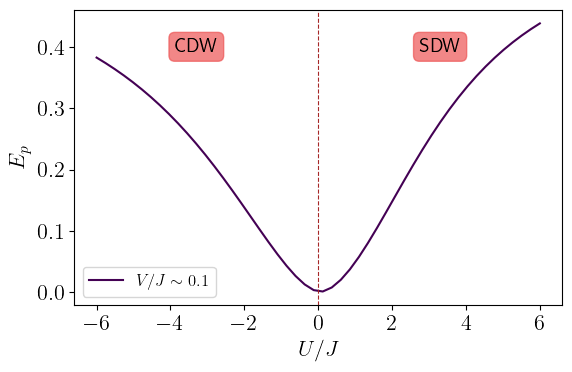

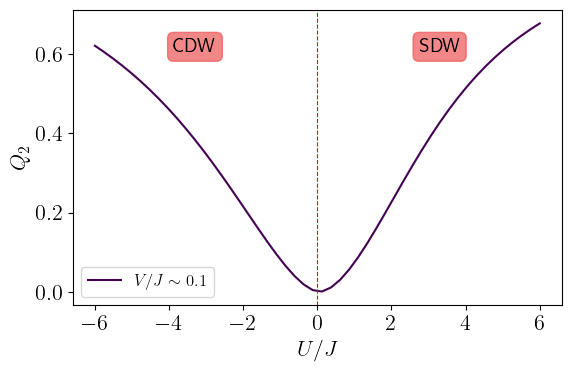

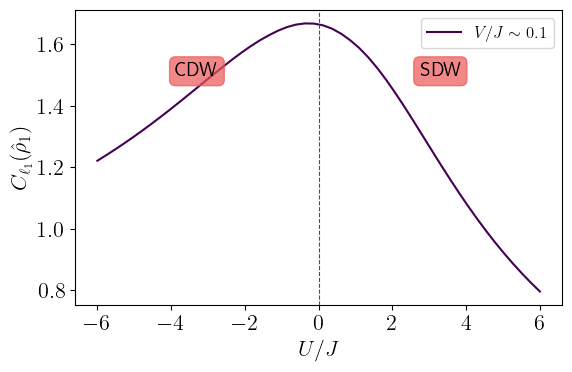

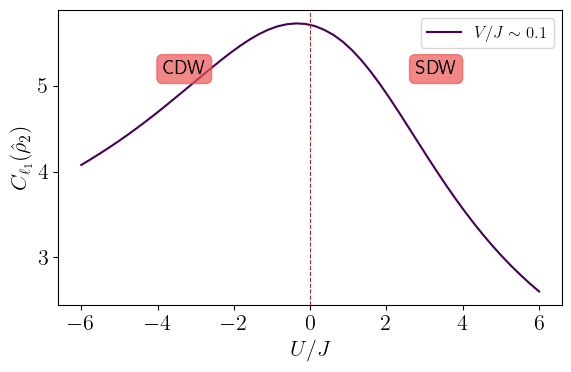

In [13]:
targets = [0.1]
x_vals = U_vals 
y_vals = V_vals 

plot_cut_phase_diagram(
    x_vals, y_vals, E_p,
    targets,
    r"$E_p$",
    r"$U/J$",
    fname=f"{figures_path}/{model}_{exec}/E_p_vs_U_V_positive_L={L}.png",
    phase_boundaries=[(0.0, "CDW"), (None, "SDW")], 
    fixed_axis="y")

plot_cut_phase_diagram(
    x_vals, y_vals, Q_2,
    targets,
    r"$Q_2$",
    r"$U/J$",
    fname=f"{figures_path}/{model}_{exec}/Q_2_vs_U_V_positive_L={L}.png",
    phase_boundaries=[(0.0, "CDW"), (None, "SDW")],
    fixed_axis="y")

plot_cut_phase_diagram(
    x_vals, y_vals, quantum_coherence_1,
    targets,
    r"$C_{\ell_{1}}(\hat{\rho}_1)$",
    r"$U/J$",
    fname=f"{figures_path}/{model}_{exec}/quantum_coherence_1rdm_vs_U_V_positive_L={L}.png",
    phase_boundaries=[(0.0, "CDW"), (None, "SDW")], 
    fixed_axis="y")

plot_cut_phase_diagram(
    x_vals, y_vals, quantum_coherence_2,
    targets,
    r"$C_{\ell_{1}}(\hat{\rho}_2)$",
    r"$U/J$",
    fname=f"{figures_path}/{model}_{exec}/quantum_coherence_2rdm_vs_U_V_positive_L={L}.png",
    phase_boundaries=[(0.0, "CDW"), (None, "SDW")], 
    fixed_axis="y")

### Plots U_targets_positive

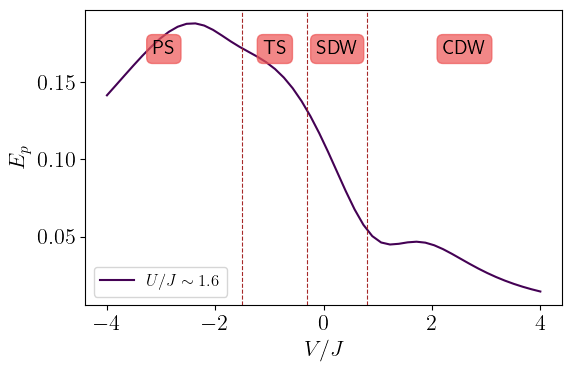

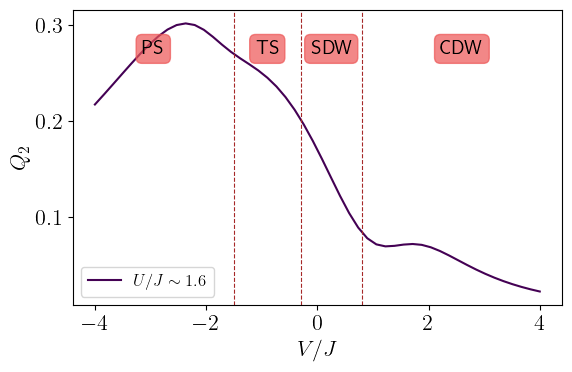

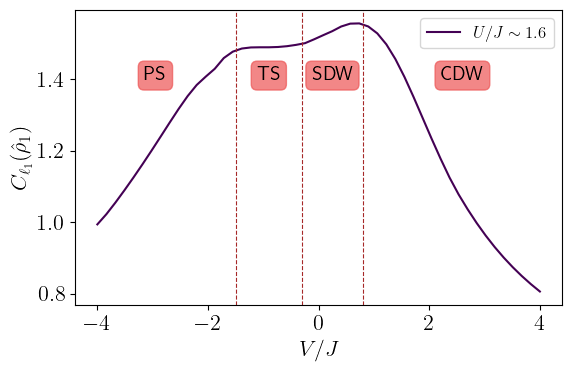

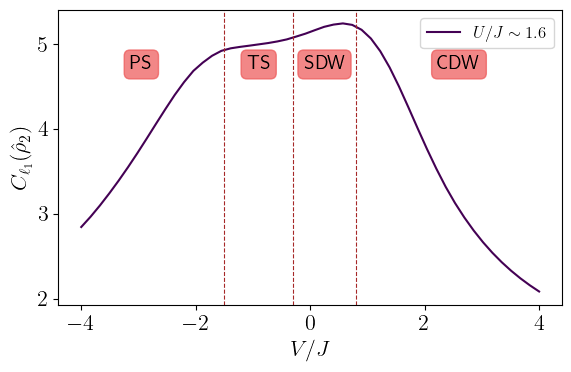

In [14]:
targets = np.sort([1.5])

x_vals = U_vals 
y_vals = V_vals 

boundaries = [(-1.5, "PS"), (-0.3, "TS"), (.8, "SDW") ,(None, "CDW")]

plot_cut_phase_diagram(
    x_vals, y_vals, 
    E_p,
    targets,
    r"$E_p$",
    r"$V/J$",
    fname=f"{figures_path}/{model}_{exec}/E_p_vs_V_U_positive_L={L}.png",
    phase_boundaries= boundaries,
    fixed_axis="x")

plot_cut_phase_diagram(
    x_vals, y_vals, 
    Q_2,
    targets,
    r"$Q_2$",
    r"$V/J$",
    fname=f"{figures_path}/{model}_{exec}/Q_2_vs_V_U_positive_L={L}.png",
    phase_boundaries=boundaries,
    fixed_axis="x")

plot_cut_phase_diagram(
    x_vals, y_vals, 
    quantum_coherence_1,
    targets,
    r"$C_{\ell_{1}}(\hat{\rho}_1)$",
    r"$V/J$",
    fname=f"{figures_path}/{model}_{exec}/quantum_coherence_1rdm_vs_V_U_positive_L={L}.png",
    phase_boundaries=boundaries, 
    fixed_axis="x")

plot_cut_phase_diagram(
    x_vals, y_vals, 
    quantum_coherence_2,
    targets,
    r"$C_{\ell_{1}}(\hat{\rho}_2)$",
    r"$V/J$",
    fname=f"{figures_path}/{model}_{exec}/quantum_coherence_2rdm_vs_V_U_positive_L={L}.png",
    phase_boundaries=boundaries,
    fixed_axis="x")

In [15]:
targets = np.sort([0.1 , 0.9, 1.6, 2.32, 1.12, 1.7, 2.1, 3.0])


def plot_measure_along_points(x_vals, y_vals, measure, targets): 
        
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = cm.viridis(np.linspace(0, 1, len(targets)))

    points = []
    # Plot data cuts
    for color, target in zip(colors, targets):
        i_fixed = np.argmin(np.abs(y_vals - target))

        points.append(measure[i_fixed])
        
        
    # ax.plot(x_vals, measure[:, i_fixed], '-', markersize=1.2, color=color,
    #                label=fr"$V / J \sim{y_vals[i_fixed]:.1f}$")

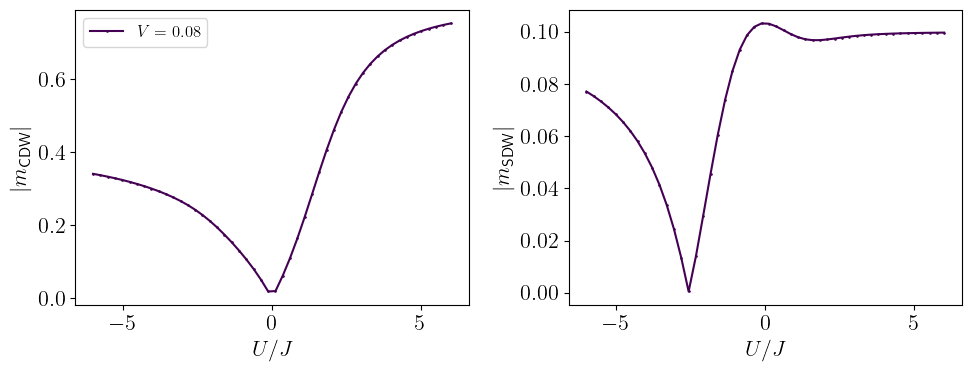

In [16]:
# Positive V plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=f"$V={V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].set_xlabel(r"$U / J$")
ax[1].set_xlabel(r"$U / J$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

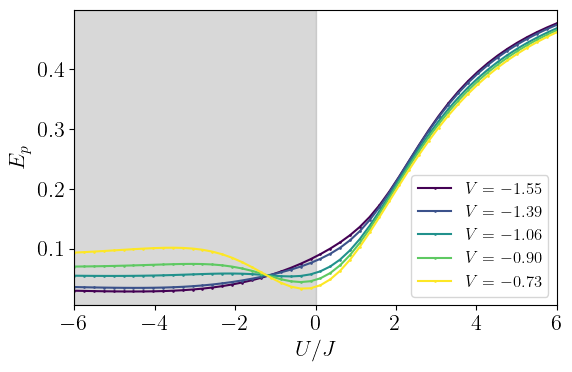

In [18]:
colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Add the grey shaded region to both subplots with zorder to place it in the background
ax.axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)

# Manually set the x-axis limits after plotting all data
ax.set_xlim(U_vals.min(), U_vals.max())

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax.plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")

ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

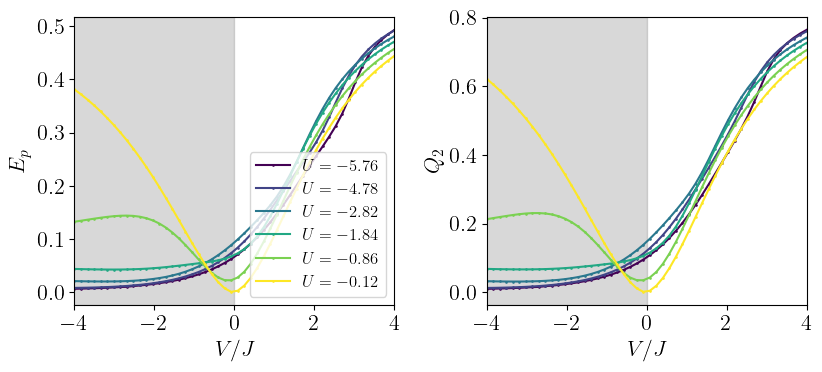

In [19]:
# Assuming all necessary variables are defined
# cm, U_targets_negatives, U_vals, V_vals, E_p, Q_2, figures_path, model, exec, and L
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 2, figsize=(8.5, 4))

# Add the grey shaded region to both subplots with zorder to place it in the background
ax[0].axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)
ax[1].axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)

# Manually set the x-axis limits after plotting all data
ax[0].set_xlim(V_vals.min(), V_vals.max())
ax[1].set_xlim(V_vals.min(), V_vals.max())

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")
ax[0].set_ylabel(r"$E_p$")
ax[1].set_ylabel(r"$Q_2$")

ax[0].legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

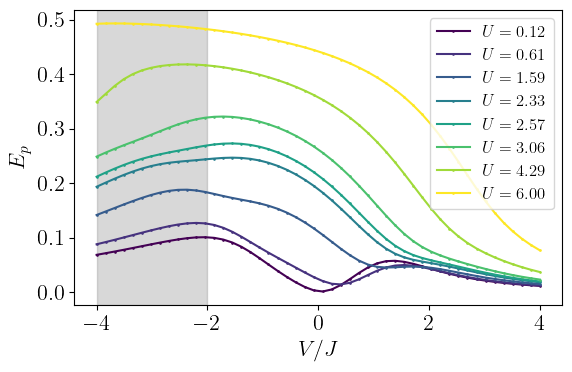

In [20]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")
# Add the grey shaded region to both subplots with zorder to place it in the background
ax.axvspan(-4.0, -2.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

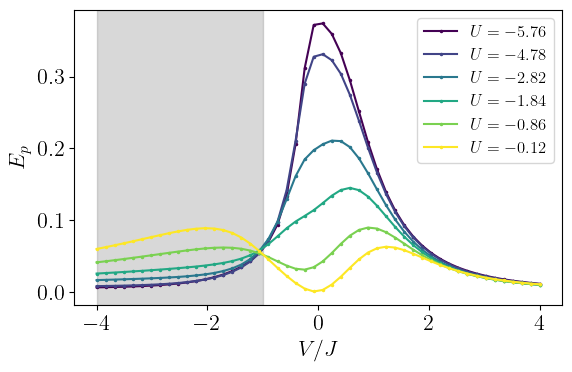

In [22]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")

ax.axvspan(-4.0, -1.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[i_U_fixed, :], 'o-', markersize=1.5, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm_L={L}_fixed_U_positive.png", dpi=500, bbox_inches='tight')
plt.show()


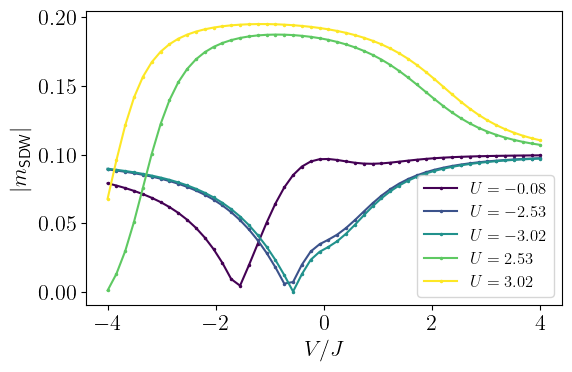

In [23]:
V_targets = [0, -2.5, -3, 2.5, 3]

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")

for color, V_target in zip(colors_neg, V_targets):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax.plot(V_vals, m_sdw[:, i_V_fixed], 'o-', markersize=1.5, color=color, label=fr"$U={V_vals[i_V_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$|m_{\text{SDW}}|$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/m_sdw_={L}_fixed_V_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

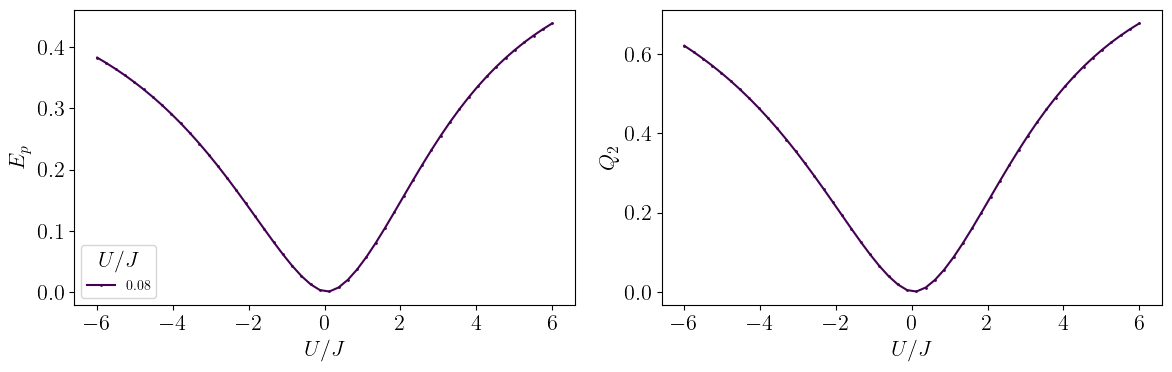

In [28]:
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals,                 E_p[:, i_V_fixed], 'o-', markersize=1.0, color=color, label=fr"${V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals,                 Q_2[:, i_V_fixed], 'o-', markersize=1.0, color=color)

ax[0].set_ylabel(r"$E_p$")
ax[0].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$Q_2$")
ax[1].set_xlabel(r"$U / J$")

# ---- Legends ----
ax[0].legend(fontsize=10, title=r"$U/J$", loc='best')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_combined_{L}.png", dpi=500, bbox_inches='tight')
plt.show()